<a href="https://colab.research.google.com/github/ChandrikaImmadi/GenAI-Tasks/blob/main/Assignment1_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk wordcloud scikit-learn tensorflow

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from tensorflow.keras.datasets import imdb

In [ ]:
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
word_index = imdb.get_word_index()
index_word = {v+3:k for k,v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def decode_review(text_ids):
    return " ".join([index_word.get(i, "?") for i in text_ids])

print("Example review:", decode_review(x_train[0]))
print("Label:", y_train[0])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Example review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole 

In [ ]:
maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [ ]:
texts = [decode_review(x) for x in x_train[:5000]]
labels = y_train[:5000]

In [ ]:
bow_vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_bow = bow_vectorizer.fit_transform(texts)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

X_train_bow, X_val_bow, y_train_bow, y_val_bow = train_test_split(X_bow, labels, test_size=0.2)
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, labels, test_size=0.2)

In [ ]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train_tfidf)
y_pred_logreg = logreg.predict(X_val_tfidf)

print("Logistic Regression Report:\n", classification_report(y_val_tfidf, y_pred_logreg))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.83       492
           1       0.81      0.90      0.86       508

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000



In [ ]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train_bow)
y_pred_nb = nb.predict(X_val_bow)

print("Naive Bayes Report:\n", classification_report(y_val_bow, y_pred_nb))

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       508
           1       0.81      0.87      0.84       492

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.83      0.83      1000



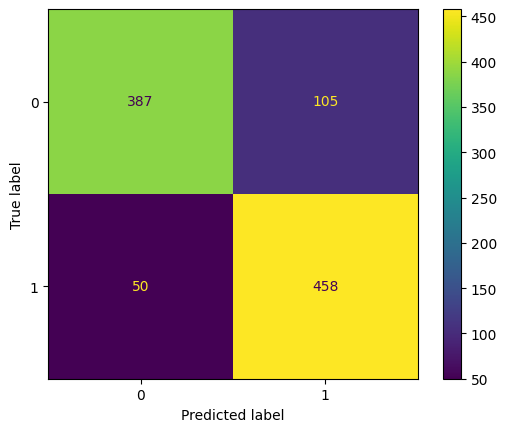

In [ ]:
cm = confusion_matrix(y_val_tfidf, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
embedding_dim = 64
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=maxlen),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 230ms/step - accuracy: 0.8068 - loss: 0.4215 - val_accuracy: 0.8621 - val_loss: 0.3343
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 210ms/step - accuracy: 0.9010 - loss: 0.2562 - val_accuracy: 0.8711 - val_loss: 0.3027
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.9261 - loss: 0.1979 - val_accuracy: 0.8690 - val_loss: 0.3392


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print("LSTM Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8690 - loss: 0.3392
LSTM Test Accuracy: 0.8689600229263306


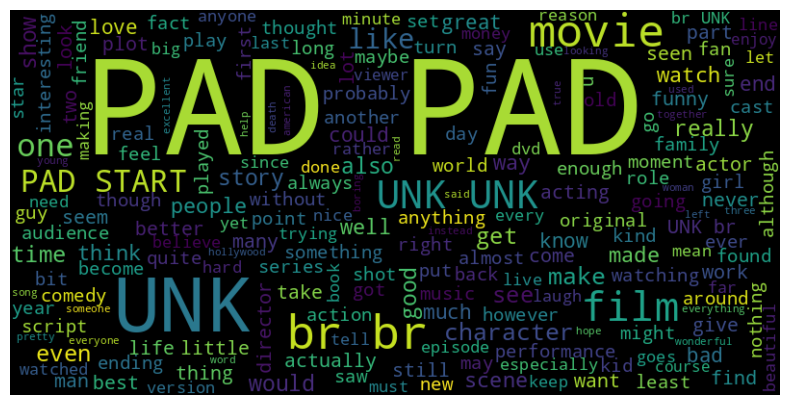

In [ ]:
all_text = " ".join(texts)
wordcloud = WordCloud(width=800, height=400, stopwords=stopwords.words('english')).generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()